# E-Commerce Sales Analysis


## Business Objective


The goal of the project is to analyze the sales data,
identify sales trends, understand order performance, and provide
actionable business recommendations.



## Business Questions

1. Which products generate the most revenue?
2. Which categories perform best?
3. How do sales change over time?
4. What percentage of orders are completed, returned and cancelled?
5. Which categories have the highest cancellation rates?
6. Are there unusual sales amount prices?

In [545]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt


# Reading the data


In [546]:
df =pd.read_csv(r"C:\Users\Anele\Downloads\retail_sales_dataset.csv")
df

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


# Initial data inspection

In [547]:
df.head(10)

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
5,ORD-03954,02/09/2024,CUST17187,Vikram Iyer,29.0,Male,West,Surat,Books,Self-Help Book,2.0,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0
6,ORD-01412,2021-09-28,CUST02453,Arjun Shah,31.0,Female,Central,Bhopal,Books,Self-Help Book,3.0,329.03,0.02,994.87,375.07,77.34,Credit Card,5.0,True,Returned,10.0
7,ORD-02911,2023-06-10,CUST23285,Aditya Sharma,43.0,Female,North,Amritsar,Clothing,Saree,1.0,1356.60,0.01,2140.41,717.27,82.68,UPI,1.0,False,Delivered,4.0
8,ORD-00465,2020-07-24,CUST23609,Aditya Patel,44.0,Female,East,Patna,Books,Self-Help Book,8.0,495.77,0.37,2828.82,1338.88,84.50,Debit Card,1.0,False,Cancelled,10.0
9,ORD-00105,2020-02-09,CUST75337,Arjun Das,17.0,FEMALE,East,Patna,Clothing,Kurta,9.0,2128.77,0.10,14568.16,4173.45,75.33,UPI,3.0,False,Delivered,8.0


In [548]:
df.shape

(4310, 21)

In [549]:
print(df.columns)

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='str')


In [550]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [551]:
df.describe() 

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000
mean,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335
std,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663
min,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000
50%,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000
max,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000


In [552]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

The data has 4310 rows and 21 columns.
The data has a missing column (quantity column).
The data has missing values.

# Data cleaning

In [553]:
df = df.drop_duplicates()
df

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [554]:
pd.set_option('display.MAX_column', None )

In [555]:
df['order_date'] = df['order_date'].str.replace(r"\D" ,"", regex= True)

df['order_date']= df['order_date'].str.replace(r"(\d{4})(\d{2})(\d{2})", r"\1-\2-\3", regex = True)
df

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [556]:
df[["first_name","last_name"]]= df[["first_name","last_name"]] = df["customer_name"].str.split(" ", expand = True)
df

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,first_name,last_name
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0,Aarav,Mehta
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0,Sanjay,Verma
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0,Pooja,Sharma
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0,Priya,Reddy
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0,Ritu,Sharma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0,Sanjay,Sharma
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0,Karan,Pillai
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0,Karan,Reddy
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0,Amit,Mehta


In [557]:
cols = df.columns.tolist()
cols.insert(3, cols.pop(cols.index('first_name')))
df = df[cols]

cols = df.columns.tolist()
cols.insert(4, cols.pop(cols.index('last_name')))
df = df[cols] 
df

,order_id,order_date,customer_id,first_name,last_name,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav,Mehta,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay,Sharma,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan,Reddy,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [558]:
df = df.drop(columns="customer_name")
df

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav,Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay,Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan,Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [559]:
df['gender'] = df['gender'].str.replace("FEMALE","Female")
df['gender'] = df['gender'].str.replace("Female","F")

df['gender'] = df['gender'].str.replace("Male","M") 
df

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav,Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay,Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,m,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan,Reddy,39.0,M,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [560]:
df['gender'] = df['gender'].str.title()
df

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav,Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay,Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,M,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan,Reddy,39.0,M,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [561]:
df["order_status"] = df["order_status"].str.title() 
df 


,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav,Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay,Sharma,45.0,F,West,Pune,Sports,Football,6.0,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,M,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan,Reddy,39.0,M,East,Guwahati,Beauty,Face Cream,7.0,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [562]:
df = df.dropna() 
df

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
5,ORD-03954,0209-20-24,CUST17187,Vikram,Iyer,29.0,M,West,Surat,Books,Self-Help Book,2.0,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4303,ORD-00450,2020-07-17,CUST20483,Kavya,Iyer,29.0,Other,South,Chennai,Furniture,Wardrobe,10.0,9945.43,0.24,94093.98,30233.13,76.34,Credit Card,3.0,False,Delivered,10.0
4304,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19.0,F,East,Guwahati,Groceries,Cooking Oil,10.0,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,M,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [563]:
df.reset_index(inplace= True)
df

,index,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,1,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
1,2,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
2,3,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
3,4,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
4,5,ORD-03954,0209-20-24,CUST17187,Vikram,Iyer,29.0,M,West,Surat,Books,Self-Help Book,2.0,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,4303,ORD-00450,2020-07-17,CUST20483,Kavya,Iyer,29.0,Other,South,Chennai,Furniture,Wardrobe,10.0,9945.43,0.24,94093.98,30233.13,76.34,Credit Card,3.0,False,Delivered,10.0
3443,4304,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19.0,F,East,Guwahati,Groceries,Cooking Oil,10.0,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9.0
3444,4306,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,M,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
3445,4308,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [564]:
df = df.drop(columns = "index") 
df

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28.0,M,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
1,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
2,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
3,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9.0,M,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
4,ORD-03954,0209-20-24,CUST17187,Vikram,Iyer,29.0,M,West,Surat,Books,Self-Help Book,2.0,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,ORD-00450,2020-07-17,CUST20483,Kavya,Iyer,29.0,Other,South,Chennai,Furniture,Wardrobe,10.0,9945.43,0.24,94093.98,30233.13,76.34,Credit Card,3.0,False,Delivered,10.0
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19.0,F,East,Guwahati,Groceries,Cooking Oil,10.0,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9.0
3444,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25.0,M,South,Chennai,Clothing,Kurta,7.0,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
3445,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40.0,F,East,Bhubaneswar,Books,Biography,5.0,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


#Converting the data-type 

In [565]:
df['age'] = df['age'].astype(int)

df['quantity'] = df['quantity'].astype(int)

df['days_to_ship'] = df['days_to_ship'].astype(int)
df


,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28,M,West,Mumbai,Beauty,Sunscreen,8,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2
1,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41,Other,West,Surat,Furniture,Sofa,4,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5
2,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29,Other,West,Ahmedabad,Furniture,Bed Frame,9,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4
3,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9,M,Central,Nagpur,Groceries,Cooking Oil,1,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4
4,ORD-03954,0209-20-24,CUST17187,Vikram,Iyer,29,M,West,Surat,Books,Self-Help Book,2,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,ORD-00450,2020-07-17,CUST20483,Kavya,Iyer,29,Other,South,Chennai,Furniture,Wardrobe,10,9945.43,0.24,94093.98,30233.13,76.34,Credit Card,3.0,False,Delivered,10
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19,F,East,Guwahati,Groceries,Cooking Oil,10,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9
3444,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25,M,South,Chennai,Clothing,Kurta,7,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2
3445,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40,F,East,Bhubaneswar,Books,Biography,5,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4


The dataset contained inconsistent values, date formats, missing values,missing columns and datatypes.

The inconsistent values,data type, date formats and columns were standardized and the missing values were removed.



In [566]:
df_cleaned = df
df_cleaned 

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-02198,2022-08-16,CUST07881,Sanjay,Verma,28,M,West,Mumbai,Beauty,Sunscreen,8,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2
1,ORD-01348,2021-08-29,CUST49296,Pooja,Sharma,41,Other,West,Surat,Furniture,Sofa,4,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5
2,ORD-02076,2022-07-05,CUST05587,Priya,Reddy,29,Other,West,Ahmedabad,Furniture,Bed Frame,9,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4
3,ORD-00287,2020-05-07,CUST58035,Ritu,Sharma,9,M,Central,Nagpur,Groceries,Cooking Oil,1,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4
4,ORD-03954,0209-20-24,CUST17187,Vikram,Iyer,29,M,West,Surat,Books,Self-Help Book,2,949.50,0.22,2202.33,964.66,62.42,Cash on Delivery,2.0,True,Returned,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,ORD-00450,2020-07-17,CUST20483,Kavya,Iyer,29,Other,South,Chennai,Furniture,Wardrobe,10,9945.43,0.24,94093.98,30233.13,76.34,Credit Card,3.0,False,Delivered,10
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19,F,East,Guwahati,Groceries,Cooking Oil,10,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9
3444,ORD-03458,2024-02-08,CUST09746,Karan,Pillai,25,M,South,Chennai,Clothing,Kurta,7,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2
3445,ORD-01738,2022-02-11,CUST50460,Amit,Mehta,40,F,East,Bhubaneswar,Books,Biography,5,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4


In [567]:
df_cleaned.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,3447.000000,3447.000000,3447.000000,3447.000000,3.447000e+03,3.447000e+03,3447.000000,3447.000000,3447.000000
mean,35.381201,7.472295,10716.073090,0.202469,6.487336e+04,1.216880e+04,63.159591,3.024659,5.638526
std,35.158191,44.828606,17425.877047,0.117280,3.480137e+05,5.818429e+04,18.394528,1.416357,4.096188
min,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,664.085000,0.100000,2.468335e+03,7.053550e+02,50.420000,2.000000,3.000000
50%,34.000000,5.000000,2232.870000,0.210000,9.791750e+03,3.205020e+03,63.200000,3.000000,6.000000
75%,42.000000,8.000000,12944.110000,0.310000,5.221250e+04,1.092780e+04,75.335000,4.000000,8.000000
max,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000


In [568]:
df_cleaned.isnull().sum()

order_id                 0
order_date               0
customer_id              0
first_name               0
last_name                0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64

## Exploratory data analysis

#Calculating the sales amount for 2024 year period 

In [569]:
df["year"] = pd.to_datetime(df["order_date"], errors="coerce")
df_2024 = df[df["year"].dt.year == 2024].copy() 
df_2024 



,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,year
14,ORD-04171,2024-12-17,CUST15084,Nikhil,Mishra,43,M,South,Kochi,Clothing,Jacket,5,3006.52,0.12,10622.32,4837.79,75.97,Credit Card,1.0,False,Delivered,5,2024-12-17
17,ORD-04158,2024-12-10,CUST75042,Pooja,Verma,44,F,Central,Nagpur,Books,Self-Help Book,7,612.70,0.22,3224.82,991.03,55.80,Credit Card,5.0,False,Delivered,4,2024-12-10
20,ORD-03795,2024-07-07,CUST28954,Nikhil,Bose,35,F,Central,Bhopal,Clothing,T-Shirt,2,735.25,0.03,2477.72,795.65,74.95,UPI,5.0,False,Delivered,8,2024-07-07
26,ORD-03422,2024-01-23,CUST58923,Deepa,Pillai,20,M,East,Guwahati,Electronics,Headphones,3,64874.09,0.02,177754.39,20320.94,79.56,UPI,1.0,False,Delivered,7,2024-01-23
28,ORD-04045,2024-10-22,CUST10094,Rahul,Sharma,26,Other,North,Amritsar,Electronics,Camera,3,68799.42,0.07,232621.97,36091.77,48.01,UPI,1.0,False,Delivered,7,2024-10-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,ORD-03812,2024-07-16,CUST84668,Aditya,Kumar,15,Other,West,Mumbai,Beauty,Shampoo,5,162.51,0.02,1292.81,494.70,66.88,EMI,3.0,False,Delivered,8,2024-07-16
3416,ORD-03596,2024-04-12,CUST47686,Ritu,Das,49,M,East,Kolkata,Electronics,Smartphone,9,64870.17,0.04,931056.13,126890.46,83.98,Cash on Delivery,4.0,False,Pending,8,2024-04-12
3423,ORD-03806,2024-07-12,CUST73502,Meera,Gupta,34,M,West,Mumbai,Clothing,Kurta,9,1781.89,0.21,20730.43,4832.00,54.08,EMI,2.0,True,Returned,5,2024-07-12
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19,F,East,Guwahati,Groceries,Cooking Oil,10,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9,2024-11-05


In [570]:
df_2024["sales_amount_original"] = df_2024["sales_amount"]
df_2024 


,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,year,sales_amount_original
14,ORD-04171,2024-12-17,CUST15084,Nikhil,Mishra,43,M,South,Kochi,Clothing,Jacket,5,3006.52,0.12,10622.32,4837.79,75.97,Credit Card,1.0,False,Delivered,5,2024-12-17,10622.32
17,ORD-04158,2024-12-10,CUST75042,Pooja,Verma,44,F,Central,Nagpur,Books,Self-Help Book,7,612.70,0.22,3224.82,991.03,55.80,Credit Card,5.0,False,Delivered,4,2024-12-10,3224.82
20,ORD-03795,2024-07-07,CUST28954,Nikhil,Bose,35,F,Central,Bhopal,Clothing,T-Shirt,2,735.25,0.03,2477.72,795.65,74.95,UPI,5.0,False,Delivered,8,2024-07-07,2477.72
26,ORD-03422,2024-01-23,CUST58923,Deepa,Pillai,20,M,East,Guwahati,Electronics,Headphones,3,64874.09,0.02,177754.39,20320.94,79.56,UPI,1.0,False,Delivered,7,2024-01-23,177754.39
28,ORD-04045,2024-10-22,CUST10094,Rahul,Sharma,26,Other,North,Amritsar,Electronics,Camera,3,68799.42,0.07,232621.97,36091.77,48.01,UPI,1.0,False,Delivered,7,2024-10-22,232621.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,ORD-03812,2024-07-16,CUST84668,Aditya,Kumar,15,Other,West,Mumbai,Beauty,Shampoo,5,162.51,0.02,1292.81,494.70,66.88,EMI,3.0,False,Delivered,8,2024-07-16,1292.81
3416,ORD-03596,2024-04-12,CUST47686,Ritu,Das,49,M,East,Kolkata,Electronics,Smartphone,9,64870.17,0.04,931056.13,126890.46,83.98,Cash on Delivery,4.0,False,Pending,8,2024-04-12,931056.13
3423,ORD-03806,2024-07-12,CUST73502,Meera,Gupta,34,M,West,Mumbai,Clothing,Kurta,9,1781.89,0.21,20730.43,4832.00,54.08,EMI,2.0,True,Returned,5,2024-07-12,20730.43
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19,F,East,Guwahati,Groceries,Cooking Oil,10,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9,2024-11-05,2696.95


In [571]:
df_2024["sales_amount_corrected"] = (
df_2024["quantity"] *
df_2024["unit_price"] *
(1 - df_2024["discount_pct"])
).round(2)

In [572]:
df_2024["sales_amount_difference"] = (
(df_2024["sales_amount_original"] -
 df_2024["sales_amount_corrected"]).round(2)
)

In [573]:
df_2024["quantity"] = df_2024["sales_amount_corrected"] / df_2024["unit_price"]
df_2024

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,year,sales_amount_original,sales_amount_corrected,sales_amount_difference
14,ORD-04171,2024-12-17,CUST15084,Nikhil,Mishra,43,M,South,Kochi,Clothing,Jacket,4.400001,3006.52,0.12,10622.32,4837.79,75.97,Credit Card,1.0,False,Delivered,5,2024-12-17,10622.32,13228.69,-2606.37
17,ORD-04158,2024-12-10,CUST75042,Pooja,Verma,44,F,Central,Nagpur,Books,Self-Help Book,5.459997,612.70,0.22,3224.82,991.03,55.80,Credit Card,5.0,False,Delivered,4,2024-12-10,3224.82,3345.34,-120.52
20,ORD-03795,2024-07-07,CUST28954,Nikhil,Bose,35,F,Central,Bhopal,Clothing,T-Shirt,1.939993,735.25,0.03,2477.72,795.65,74.95,UPI,5.0,False,Delivered,8,2024-07-07,2477.72,1426.38,1051.34
26,ORD-03422,2024-01-23,CUST58923,Deepa,Pillai,20,M,East,Guwahati,Electronics,Headphones,2.940000,64874.09,0.02,177754.39,20320.94,79.56,UPI,1.0,False,Delivered,7,2024-01-23,177754.39,190729.82,-12975.43
28,ORD-04045,2024-10-22,CUST10094,Rahul,Sharma,26,Other,North,Amritsar,Electronics,Camera,2.790000,68799.42,0.07,232621.97,36091.77,48.01,UPI,1.0,False,Delivered,7,2024-10-22,232621.97,191950.38,40671.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3415,ORD-03812,2024-07-16,CUST84668,Aditya,Kumar,15,Other,West,Mumbai,Beauty,Shampoo,4.900006,162.51,0.02,1292.81,494.70,66.88,EMI,3.0,False,Delivered,8,2024-07-16,1292.81,796.30,496.51
3416,ORD-03596,2024-04-12,CUST47686,Ritu,Das,49,M,East,Kolkata,Electronics,Smartphone,8.640000,64870.17,0.04,931056.13,126890.46,83.98,Cash on Delivery,4.0,False,Pending,8,2024-04-12,931056.13,560478.27,370577.86
3423,ORD-03806,2024-07-12,CUST73502,Meera,Gupta,34,M,West,Mumbai,Clothing,Kurta,7.110001,1781.89,0.21,20730.43,4832.00,54.08,EMI,2.0,True,Returned,5,2024-07-12,20730.43,12669.24,8061.19
3443,ORD-04082,2024-11-05,CUST72244,Aditya,Patel,19,F,East,Guwahati,Groceries,Cooking Oil,6.800000,400.50,0.32,2696.95,174.53,55.61,EMI,4.0,False,Delivered,9,2024-11-05,2696.95,2723.40,-26.45


#checking the product category count, the mean of a quantity, and the minimum and maximum sales amount prices 

In [574]:
df_2024.groupby("product_category")["year"].count()  

product_category
Beauty          99
Books           80
Clothing       101
Electronics    109
Furniture       80
Groceries       84
Sports          66
Name: year, dtype: int64

In [575]:
quantity_mean = df_2024["quantity"].mean()
print("quantity_mean", quantity_mean)

quantity_mean 4.186865791490227


In [576]:
sales_amount_corrected_min = df_2024["sales_amount_corrected"].min() 
print("sales_amount_corrected_min", sales_amount_corrected_min)

sales_amount_corrected_corrected_max = df_2024["sales_amount_corrected"].max()
print("sales_amount_corrected_max", sales_amount_corrected_corrected_max)

sales_amount_corrected_min -14445.94
sales_amount_corrected_max 635174.86


In [577]:
df_2024.drop(columns =["sales_amount"],inplace = True)

In [578]:
cols = df_2024.columns.to_list()
cols.insert(14, cols.pop( cols.index("sales_amount_original")))
df_2024 = df_2024[cols] 

cols = df_2024.columns.to_list()
cols.insert( 15, cols.pop(cols.index("sales_amount_corrected"))) 
df_2024 = df_2024[cols]

cols = df_2024.columns.to_list()
cols.insert(16, cols.pop(cols.index("sales_amount_difference")))
df_2024 = df_2024[cols] 

#Caculating sales amount for 2023 year period 

In [579]:
df["year"] = pd.to_datetime(df["order_date"], errors="coerce")
df_2023 = df[df["year"].dt.year == 2023].copy() 
df_2023

,order_id,order_date,customer_id,first_name,last_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,year
6,ORD-02911,2023-06-10,CUST23285,Aditya,Sharma,43,F,North,Amritsar,Clothing,Saree,1,1356.60,0.01,2140.41,717.27,82.68,UPI,1.0,False,Delivered,4,2023-06-10
24,ORD-02684,2023-03-10,CUST32875,Kavya,Patel,41,M,South,Kochi,Beauty,Hair Oil,3,1290.21,0.12,3690.09,1777.76,64.97,Cash on Delivery,3.0,False,Delivered,5,2023-03-10
29,ORD-02565,2023-01-17,CUST71120,Ritu,Nair,35,M,North,Amritsar,Furniture,Sofa,3,31242.32,0.01,92924.36,27403.47,52.73,Debit Card,3.0,True,Returned,4,2023-01-17
32,ORD-02868,2023-05-31,CUST17518,Sanjay,Shah,42,F,Central,Indore,Furniture,Wardrobe,6,20242.36,0.04,191398.26,59116.34,83.75,Credit Card,2.0,False,Delivered,9,2023-05-31
36,ORD-03357,2023-12-23,CUST53286,Kavya,Verma,34,M,East,Patna,Beauty,Face Cream,5,2497.10,0.37,6596.23,2649.20,61.27,Cash on Delivery,1.0,False,Shipped,5,2023-12-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3432,ORD-02916,2023-06-14,CUST68649,Rahul,Patel,20,Other,South,Chennai,Groceries,Dal (1kg),8,246.15,0.21,2555.54,179.49,95.73,Net Banking,1.0,False,Delivered,2,2023-06-14
3433,ORD-03350,2023-12-20,CUST53832,Rahul,Mehta,14,F,North,Ludhiana,Clothing,Jeans,5,645.04,0.13,2174.45,643.44,51.85,Credit Card,5.0,False,Delivered,8,2023-12-20
3437,ORD-02879,2023-06-02,CUST55177,Ananya,Reddy,27,Other,East,Kolkata,Groceries,Sugar,6,386.80,0.21,3078.58,318.39,79.26,EMI,1.0,False,Shipped,5,2023-06-02
3438,ORD-02811,2023-05-04,CUST06279,Amit,Joshi,35,F,North,Ludhiana,Beauty,Lipstick,10,239.33,0.23,2481.93,780.04,61.70,Net Banking,4.0,False,Delivered,10,2023-05-04


In [580]:
df_2023["sales_amount_original"] = df_2023["sales_amount"]
 


In [581]:
df_2023["sales_amount_corrected"] = (
df_2023["quantity"] *
df_2023["unit_price"] *
(1 - df_2024["discount_pct"])
).round(2)

Data quality issue identified: 
The original Sales Amount variable was found to be inconsistent with the expected calculation. Based on the available variables, Sales Amount should be calculated as Quantity × Unit Price × (1 − Discount Percentage). The original Sales Amount values were therefore validated against this formula, and the corrected values were used for subsequent revenue analysis. 



Calculating the total revenue for the year 2024 amd 2023.
Calculating the sales growth percentage. 

In [582]:
total_revenue_2024 = round( df_2024["sales_amount_corrected"].sum(),2)
print("KPI -> total_revenue_2024:", total_revenue_2024) 

KPI -> total_revenue_2024: 30406116.44


In [583]:
total_revenue_2023 = round(df_2023["sales_amount_original"].sum(),2)
print(total_revenue_2023)

49609768.23


In [584]:
sales_growth_pct = round((total_revenue_2024 - total_revenue_2023 ) / total_revenue_2023 * 100,2)
print(" KPI -> sales_growth_pct:", sales_growth_pct) 

 KPI -> sales_growth_pct: -38.71


The Sales growth for the year 2024 significantly decreased by -38.71% compared to the previous year 2023's Sales growth.

Calculating the percentage of order statuses 

In [585]:
total_orders = df_2024["order_status"].count() 
print("KPI -> total_orders:", total_orders)

KPI -> total_orders: 619


In [586]:
Delivered_orders_pct = (
round(df_2024["order_status"].eq("Delivered").sum() /
 total_orders * 100, 2)) 
print("Delivered_orders_pct:", Delivered_orders_pct)  


Returned_orders_pct = (
round(df_2024["order_status"].eq("Returned").sum() /
 total_orders * 100, 2)) 
print("Returned_orders_pct:", Returned_orders_pct) 


Cancelled_orders_pct = (
round(df_2024["order_status"].eq("Cancelled").sum() /
 total_orders * 100, 2)) 
print("Cancelled_orders_pct:", Cancelled_orders_pct)  

Delivered_orders_pct: 67.85
Returned_orders_pct: 12.92
Cancelled_orders_pct: 8.24


The delivered orders percentage is 67.85 % ranking the highest, followed by Returned order percentage at 12.92% and at the lowerst we have 8.24% for cancelled orders.

Defining unusual sales amount prices 

14      False
17      False
20      False
26       True
28       True
        ...  
3415    False
3416     True
3423    False
3443    False
3444    False
Name: sales_amount_corrected, Length: 619, dtype: bool

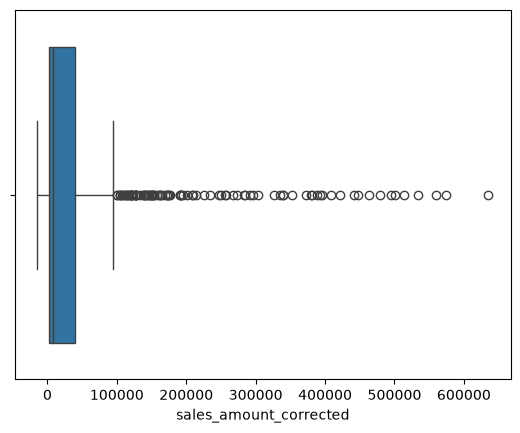

In [587]:
sns.boxplot(x = df_2024["sales_amount_corrected"])

df_2024["sales_amount_corrected"].quantile([0.25, 0.75]) 
Q1 = 2255.64
Q3 = 40085.65

IQR = Q3 - Q1 
40085.65 - 2255.64
IQR = 37830.01

Lower_limit = 2222.64 + (1.5 * 37830.01)
Lower_limit = 59000.66 

Upper_limit = 40085.65 + (1.5 * 37830.01)
Upper_limit = 96830.67

df_2024["sales_amount_corrected"] < Lower_limit
df_2024["sales_amount_corrected"] > Upper_limit



The outliers were investigated rather than automatically removed. Extreme values may represent genuine high-value transactions, so they will only be removed if there is evidence that thet are data entry errors. 

# Business Question 1

##Which product generates the most revenue?

In [588]:
product_category = (
    df_2024.groupby("product_category")
    ['sales_amount_corrected'].sum()
    .sort_values(ascending= True)
)
product_category

product_category
Groceries        104491.54
Books            278574.57
Beauty           575418.31
Clothing         853535.72
Sports          1760040.37
Furniture       6675985.54
Electronics    20158070.39
Name: sales_amount_corrected, dtype: float64

<Axes: title={'center': 'Revenue by product category'}, xlabel='product_category', ylabel='Revenue'>

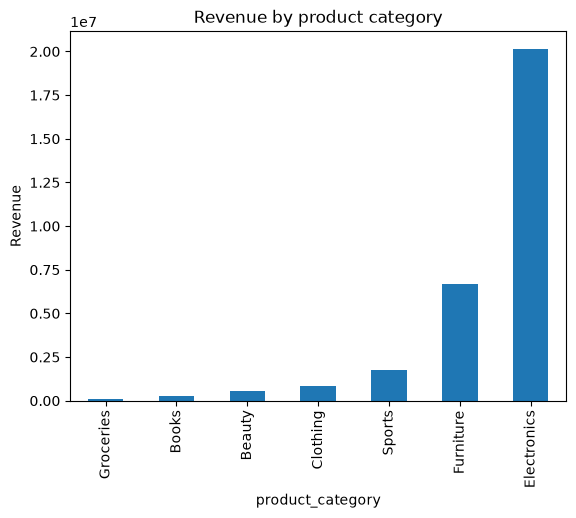

In [589]:
product_category.plot(kind = 'bar', 
title ="Revenue by product category",
xlabel= "product_category",
ylabel = "Revenue") 



## Findigs

The Electronics category experienced the highest increase in sales compared with the other product categories. This indicates strong growth in demand for electronics during the period analysed and contributed positively to overall sales performance.

# Business Question 2

Which product name performed the best?

In [590]:
product_name = (
    df_2024.groupby("product_name")
    ['sales_amount_corrected'].sum()
    .sort_values(ascending= False)
)
product_name

product_name
Headphones        3861062.12
Smartwatch        3709917.64
Laptop            3213780.46
Smartphone        3204048.64
Camera            3128614.88
Tablet            3040646.65
Desk              1608066.10
Bed Frame         1191669.15
Chair             1168040.57
Sofa              1002409.32
Wardrobe           890209.42
Bookshelf          815590.98
Tennis Racket      379589.95
Dumbbells          368885.36
Cricket Bat        360514.64
Yoga Mat           276786.27
Cycle              224713.76
Sunscreen          184544.66
Kurta              182905.54
Jacket             167008.62
Saree              163251.26
Face Cream         155595.69
Football           149550.39
Dress              144768.20
Jeans              104527.51
T-Shirt             91074.59
Lipstick            75638.46
Self-Help Book      74207.83
Perfume             70227.67
Fiction Novel       62990.25
Shampoo             53755.18
Biography           50064.52
Textbook            42964.33
Hair Oil            35656.65
C

<Axes: title={'center': 'Top 6 product by revenue'}, xlabel='product_name', ylabel='Revenue'>

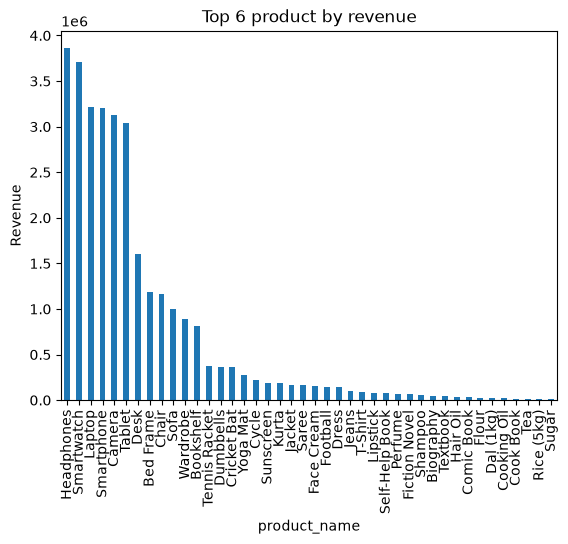

In [591]:
product_name.plot(kind = 'bar',
title= "Top 6 product by revenue",
ylabel= "Revenue")

# Findings

The Headphone is the best performing product followed by Smartwatch in the second place, followed by the Smartwatch product and the Sugar,Rice,Tea products that are in the groceries category are their revenue performance is significantly low.

# Business Question 3

What is the sales change over time?

In [592]:
df_2024["month"] = df_2024["year"].dt.to_period("M") 

monthly_sales = df_2024.groupby("month")["sales_amount_corrected"].sum() 
monthly_sales

month
2024-01    2148104.60
2024-02    2906223.92
2024-03    3381817.25
2024-04    3459000.88
2024-05     994672.56
2024-06    2884021.82
2024-07    2619607.70
2024-08    3823273.56
2024-09    1231751.66
2024-10    1756509.00
2024-11    3075394.31
2024-12    2125739.18
Freq: M, Name: sales_amount_corrected, dtype: float64

<Axes: title={'center': 'Monthly Revenue'}, xlabel='Monthly', ylabel='Revenue'>

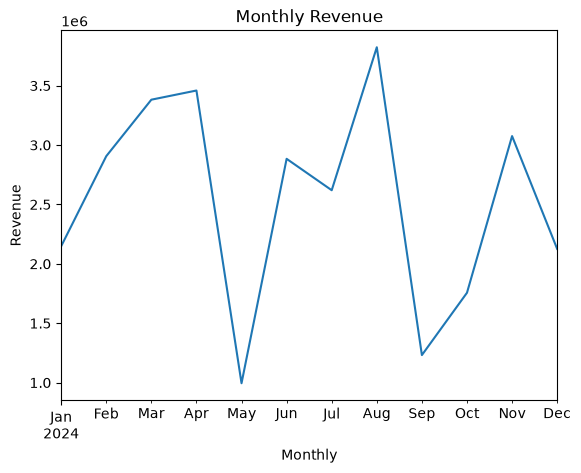

In [593]:
monthly_sales.plot(kind = 'line',
title = ('Monthly Revenue'),
xlabel = "Monthly",
ylabel = "Revenue") 

# Findings

The Sales revenue for the year 2024 declined significantly during the start of the second quarter in May and during the start of the fourth quarter in September, suggesting that the decrease in overall annual sales was concentrated during these periods.

# Business Question 4

What is the percentage of orders that are Completed,Returned,Cancelled?

In [594]:
order_status_percentage = (
df_2024["order_status"].value_counts(normalize= total_revenue_2024) * 100
)
order_status_percentage

order_status
Delivered    67.851373
Returned     12.924071
Cancelled     8.239095
Shipped       7.431341
Pending       3.554120
Name: proportion, dtype: float64

<Axes: title={'center': 'Order Status Destribution'}, xlabel='Percentage of Orders', ylabel='order_status'>

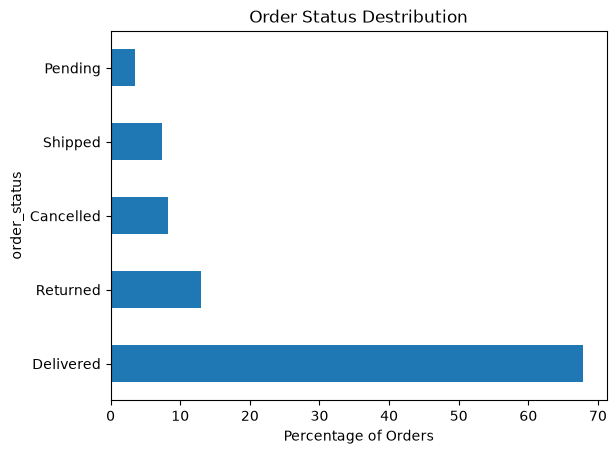

In [595]:
order_status_percentage.plot(kind = 'barh',
title = ("Order Status Destribution"),
xlabel = "Percentage of Orders") 

# Findings

The delivered orders had a significant increase in the order distribution status, suggesting that a relatave large portion of orders  were succesfully delevered without any hurdles.  

# Business Question 5 

Which category has the highest cancellation rate?

In [596]:
product_category_cancel_rate = (
df_2024.groupby("product_category")["order_status"]
.apply(lambda x :(x =="Cancelled").sum()/ len(x) * 100).round(2)
)
product_category_cancel_rate 

product_category
Beauty         12.12
Books           6.25
Clothing        8.91
Electronics     6.42
Furniture       7.50
Groceries       8.33
Sports          7.58
Name: order_status, dtype: float64

<Axes: >

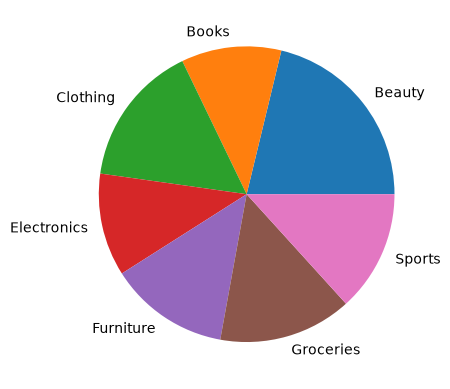

In [597]:
product_category_cancel_rate.plot(kind = "pie") 

# Findings

The Beauty category has the highest order cancellation rate among all product categories. This indicates that a relatively large proportion of Beauty orders were cancelled compared with other categories. Further investigation is needed to determine the reasons for these cancellations, such as product availability, delivery issues, pricing or customer preferences.

# Key findings

### 1. Revenue
Electronics generated the highest revenue.

### 2. Product performance
A small number of products contibuted a large proportion of sales.

### 3. Order status
Most orders were delivered, whiele a smaller percentage remained retuned and were cancelled.

### 4. Cancellations
Certain categories showed higher cancellation rates than others.

### 5. Outliers
Unusually large transactions were identified and investigated.

# Business recommendations

1. Icrease inventory availibility for high performing products.
2. Invest categories with high cncellation rate
3. Analyse the causes of cancelled orders before increasing marketing spend in those categories.
4. Monitor unusuallty large transactions to distiguish genuine high value orders from data entry errors.
5. Use the monthly sales trend to improve Inventory and promotional planning.

# Conclusion

The analysis provides insights into e-commerce sales performance and highlights areas where the business can investigate declining sales, order cancellations, and changes in product-category performance.